# Task 1

In [1]:
import pandas as pd

file_path = "DecodeX_VoltRide_Dataset.xlsx"

zone_df = pd.read_excel(file_path, sheet_name = "Zone_Hour_Demand")
ride_df = pd.read_excel(file_path, sheet_name = "Ride_Level_Data")

In [2]:
zone_df.head()

,City,Zone,Hour,Avg_Ride_Requests,Avg_Cancellations
0,Mumbai,1,0,177,6
1,Mumbai,1,1,133,13
2,Mumbai,1,2,96,15
3,Mumbai,1,3,94,16
4,Mumbai,1,4,180,5


In [3]:
ride_df.head()

,Ride_ID,City,Date,Hour,Pickup_Zone,Drop_Zone,Ride_Distance_km,Estimated_Fare,Surge_Multiplier,EV_Battery_%,Driver_Available,Charging_Station_Nearby,Weather,Ride_Status,Cancellation_By
0,1,Hyderabad,2025-01-01,5,8,3,21.59,374.64,2.0,29,Yes,Yes,Heavy Rain,Completed,NaN
1,2,Mumbai,2025-01-01,13,5,4,4.70,353.66,1.0,61,Yes,No,Rain,Completed,NaN
2,3,Delhi,2025-01-01,11,5,5,3.52,329.88,2.0,30,Yes,Yes,Clear,Completed,NaN
3,4,Bengaluru,2025-01-01,22,9,7,21.28,628.14,2.0,17,Yes,Yes,Clear,Cancelled,System
4,5,Hyderabad,2025-01-01,19,5,2,7.00,526.89,1.5,34,Yes,No,Rain,Completed,NaN


In [4]:
zone_df["Cancellation_Rate"] = zone_df["Avg_Cancellations"] / zone_df["Avg_Ride_Requests"]

In [5]:
zone_df["Avg_Ride_Requests"].mean()

np.float64(113.03541666666666)

In [6]:
zone_df["Cancellation_Rate"].mean()

np.float64(0.24030972249047056)

In [7]:
stress_df = zone_df[
    (zone_df["Avg_Ride_Requests"] > zone_df["Avg_Ride_Requests"].mean()) &
    (zone_df["Cancellation_Rate"] > zone_df["Cancellation_Rate"].mean())
]

stress_df.head()

,City,Zone,Hour,Avg_Ride_Requests,Avg_Cancellations,Cancellation_Rate
9,Mumbai,1,9,114,38,0.333333
40,Mumbai,2,16,145,39,0.268966
90,Mumbai,4,18,136,39,0.286765
103,Mumbai,5,7,134,33,0.246269
127,Mumbai,6,7,128,32,0.250000


In [8]:
stress_df.sort_values(by="Cancellation_Rate", ascending=False).head(10)

,City,Zone,Hour,Avg_Ride_Requests,Avg_Cancellations,Cancellation_Rate
9,Mumbai,1,9,114,38,0.333333
277,Delhi,2,13,116,38,0.327586
654,Bengaluru,8,6,119,38,0.319328
392,Delhi,7,8,121,38,0.314050
733,Hyderabad,1,13,115,36,0.313043
268,Delhi,2,4,119,37,0.310924
164,Mumbai,7,20,117,36,0.307692
841,Hyderabad,6,1,124,38,0.306452
542,Bengaluru,3,14,121,37,0.305785
432,Delhi,9,0,126,38,0.301587


In [9]:
X = "Mumbai"
Y = 1
Z = 9

In [10]:
candidate = ride_df[
    (ride_df["City"] == X) &
    (ride_df["Pickup_Zone"] == Y) &
    (ride_df["Hour"] == Z)
]
candidate

,Ride_ID,City,Date,Hour,Pickup_Zone,Drop_Zone,Ride_Distance_km,Estimated_Fare,Surge_Multiplier,EV_Battery_%,Driver_Available,Charging_Station_Nearby,Weather,Ride_Status,Cancellation_By
110,111,Mumbai,2025-01-05,9,1,1,3.87,759.27,1.2,64,Yes,Yes,Clear,Completed,NaN
446,447,Mumbai,2025-01-19,9,1,10,22.88,576.37,2.0,81,Yes,Yes,Clear,Completed,NaN
1201,1202,Mumbai,2025-02-20,9,1,3,18.70,744.11,2.0,81,Yes,Yes,Clear,Completed,NaN
1900,1901,Mumbai,2025-03-21,9,1,9,6.90,763.95,1.0,68,Yes,Yes,Rain,Completed,NaN


In [11]:
candidate["EV_Battery_%"].describe()

count     4.000000
mean     73.500000
std       8.812869
min      64.000000
25%      67.000000
50%      74.500000
75%      81.000000
max      81.000000
Name: EV_Battery_%, dtype: float64

In [12]:
(candidate["EV_Battery_%"] < 30).mean()

np.float64(0.0)

In [13]:
candidate["Weather"].value_counts()

Weather
Clear    3
Rain     1
Name: count, dtype: int64

In [14]:
candidate["Driver_Available"].value_counts()

Driver_Available
Yes    4
Name: count, dtype: int64

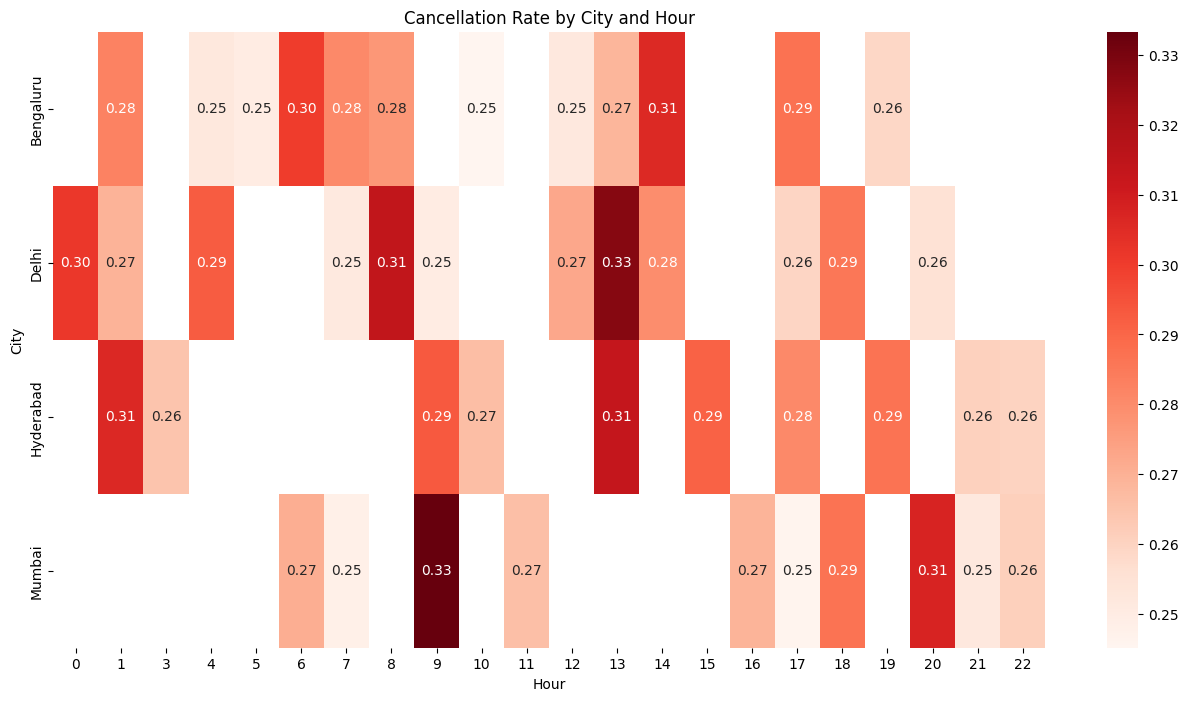

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pivot_cancel = stress_df.pivot_table(
    values='Cancellation_Rate',
    index='City',
    columns='Hour',
    aggfunc='mean'
)

plt.figure(figsize=(16,8))
sns.heatmap(pivot_cancel, annot=True, cmap='Reds', fmt=".2f")
plt.title("Cancellation Rate by City and Hour")
plt.ylabel("City")
plt.xlabel("Hour")
plt.show()

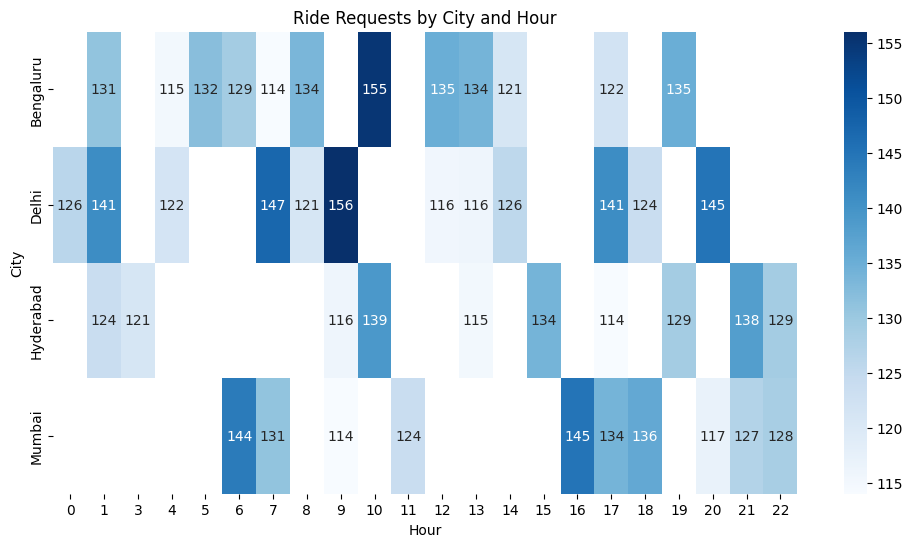

In [16]:
pivot_demand = stress_df.pivot_table(
    values='Avg_Ride_Requests',
    index='City',
    columns='Hour',
    aggfunc='mean'
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot_demand, annot=True, cmap='Blues', fmt=".0f")
plt.title("Ride Requests by City and Hour")
plt.ylabel("City")
plt.xlabel("Hour")
plt.show()

# Task 2

In [17]:
cancelled = ride_df[ride_df["Ride_Status"] == "Cancelled"]

In [20]:
surge_cancel = cancelled[cancelled["Surge_Multiplier"] > 1.5].shape[0]
surge_cancel

203

In [22]:
battery_cancel = cancelled[cancelled["EV_Battery_%"] < 25].shape[0]

In [33]:
driver_cancel = cancelled[cancelled["Driver_Available"] == "No"].shape[0]

In [34]:
weather_cancel = cancelled[cancelled["Weather"] == "Rain"].shape[0]

In [35]:
total_cancel = cancelled.shape[0]

print("Surge %:", surge_cancel/total_cancel)
print("Battery %:", battery_cancel/total_cancel)
print("Driver %:", driver_cancel/total_cancel)
print("Weather %:", weather_cancel/total_cancel)

Surge %: 0.2746955345060893
Battery %: 0.21380243572395127
Driver %: 0.41271989174560214
Weather %: 0.2543978349120433


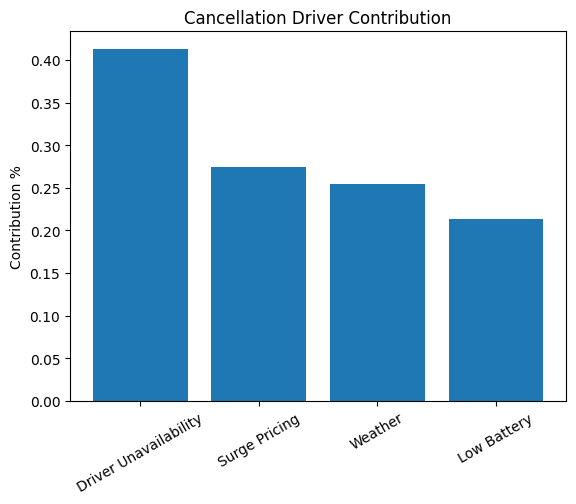

In [36]:
import matplotlib.pyplot as plt

drivers = ["Driver Unavailability", "Surge Pricing", "Weather", "Low Battery"]
values = [0.4127, 0.2747, 0.2544, 0.2138]

plt.figure()
plt.bar(drivers, values)
plt.title("Cancellation Driver Contribution")
plt.ylabel("Contribution %")
plt.xticks(rotation=30)
plt.show()

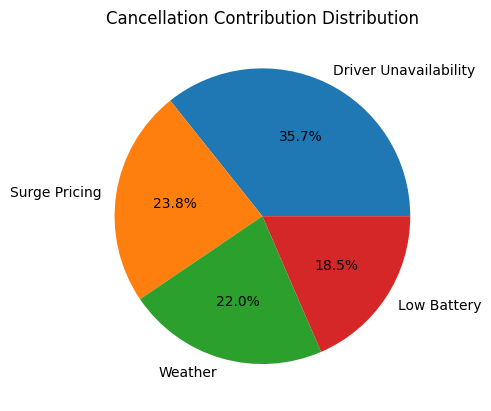

In [37]:
plt.figure()
plt.pie(values, labels=drivers, autopct='%1.1f%%')
plt.title("Cancellation Contribution Distribution")
plt.show()

# TASK 3

In [9]:
import pandas as pd

df = pd.read_excel("DecodeX_VoltRide_Dataset.xlsx", sheet_name="Ride_Level_Data")
df.head()


,Ride_ID,City,Date,Hour,Pickup_Zone,Drop_Zone,Ride_Distance_km,Estimated_Fare,Surge_Multiplier,EV_Battery_%,Driver_Available,Charging_Station_Nearby,Weather,Ride_Status,Cancellation_By
0,1,Hyderabad,2025-01-01,5,8,3,21.59,374.64,2.0,29,Yes,Yes,Heavy Rain,Completed,NaN
1,2,Mumbai,2025-01-01,13,5,4,4.70,353.66,1.0,61,Yes,No,Rain,Completed,NaN
2,3,Delhi,2025-01-01,11,5,5,3.52,329.88,2.0,30,Yes,Yes,Clear,Completed,NaN
3,4,Bengaluru,2025-01-01,22,9,7,21.28,628.14,2.0,17,Yes,Yes,Clear,Cancelled,System
4,5,Hyderabad,2025-01-01,19,5,2,7.00,526.89,1.5,34,Yes,No,Rain,Completed,NaN


In [11]:
zone_summary = df.groupby(['City', 'Pickup_Zone', 'Ride_Status']).size().unstack(fill_value=0).reset_index()
zone_summary.head()

Ride_Status,City,Pickup_Zone,Cancelled,Completed
0,Bengaluru,1,14,38
1,Bengaluru,2,12,46
2,Bengaluru,3,16,43
3,Bengaluru,4,28,39
4,Bengaluru,5,15,50


In [13]:
zone_summary['Total_Rides'] = zone_summary.get('Cancelled', 0) + zone_summary.get('Completed', 0)
zone_summary['Cancellation_Rate'] = zone_summary['Cancelled'] / zone_summary['Total_Rides']

In [15]:
driver_availability = df.groupby(['City', 'Pickup_Zone'])['Driver_Available'].value_counts(normalize=True).unstack(fill_value=0).reset_index()
driver_availability.head()

Driver_Available,City,Pickup_Zone,No,Yes
0,Bengaluru,1,0.096154,0.903846
1,Bengaluru,2,0.051724,0.948276
2,Bengaluru,3,0.152542,0.847458
3,Bengaluru,4,0.149254,0.850746
4,Bengaluru,5,0.138462,0.861538


In [ ]:
zone_full = pd.merge(zone_summary, driver_availability, on=['City', 'Pickup_Zone'])
zone_full.head()

# TASK 4

In [38]:
import pandas as pd
zone_df = pd.read_excel("DecodeX_VoltRide_Dataset.xlsx", sheet_name="Zone_Hour_Demand")
charging_df = pd.read_excel("DecodeX_VoltRide_Dataset.xlsx", sheet_name="Charging_Stations")

In [39]:
merged_df = pd.merge(
    zone_df,
    charging_df,
    on=["City", "Zone"]
)

merged_df.head()

,City,Zone,Hour,Avg_Ride_Requests,Avg_Cancellations,Station_ID,Chargers_Available,Avg_Wait_Time_Min
0,Mumbai,1,0,177,6,CS215,4,27
1,Mumbai,1,0,177,6,CS228,4,31
2,Mumbai,1,1,133,13,CS215,4,27
3,Mumbai,1,1,133,13,CS228,4,31
4,Mumbai,1,2,96,15,CS215,4,27


In [50]:
charging_stress = merged_df[
    (merged_df["Avg_Wait_Time_Min"] > merged_df["Avg_Wait_Time_Min"].mean()) &
    (merged_df["Chargers_Available"] > 0)
]

charging_stress[["City", "Zone", "Hour", "Avg_Ride_Requests", "Chargers_Available", "Avg_Wait_Time_Min"]].sort_values("Avg_Wait_Time_Min", ascending=False).head(10)

,City,Zone,Hour,Avg_Ride_Requests,Chargers_Available,Avg_Wait_Time_Min
839,Hyderabad,6,23,91,3,34
837,Hyderabad,6,22,136,3,34
835,Hyderabad,6,21,53,3,34
833,Hyderabad,6,20,88,3,34
831,Hyderabad,6,19,33,3,34
829,Hyderabad,6,18,80,3,34
827,Hyderabad,6,17,82,3,34
825,Hyderabad,6,16,101,3,34
809,Hyderabad,6,8,75,3,34
811,Hyderabad,6,9,167,3,34


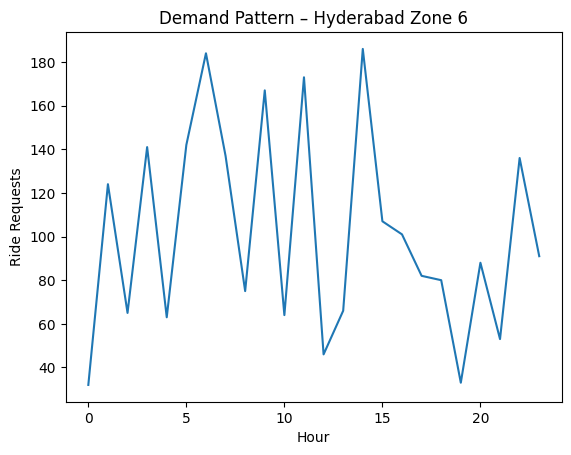

In [46]:
zone6 = merged_df[
    (merged_df["City"] == "Hyderabad") &
    (merged_df["Zone"] == 6)
]

import matplotlib.pyplot as plt

plt.figure()
plt.plot(zone6["Hour"], zone6["Avg_Ride_Requests"])
plt.title("Demand Pattern – Hyderabad Zone 6")
plt.xlabel("Hour")
plt.ylabel("Ride Requests")
plt.show()